In [1]:

import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
import xarray as xr
import h5py

from scipy.optimize import least_squares

In [2]:
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1

Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)

Ec= 0.21e9*h #JAC
C = e**2/(2*Ec) #F
T = 15e-3 #K
Delta_Al = 3.4e-4*e # J

E_J = 20e9*h #Hz

In [3]:
def drop_duplicates(ds, dim):
    """Drop duplicates if dim exists, otherwise return dataset unchanged."""
    if dim not in ds:
#         print(f"Warning: dimension '{dim}' not found in dataset. Skipping drop_duplicates.")
        return ds
    _, index = np.unique(ds[dim], return_index=True)
    return ds.isel({dim: index})

def load_dataset(key: str):
    """Load dataset(s) based on key and return processed xarray.Dataset + flux_shift."""
    if key not in DATASETS01:
        raise ValueError(f"Key '{key}' not in DATASETS. Available: {list(DATASETS.keys())}")

    entry = DATASETS01[key]
    
    # Load main dataset
    ds_main = xr.load_dataset(entry["main"])
    ds_main = drop_duplicates(ds_main, "bias")

    # Load close dataset if available
    if entry["close"] is not None:
        ds_close = xr.load_dataset(entry["close"])
        ds_close = drop_duplicates(ds_close, "bias")
        ds = xr.merge([ds_main, ds_close], join="outer", compat="no_conflicts")
    else:
        ds = ds_main

    return ds, entry["flux_shift"]


In [4]:
def drop_duplicates(ds, dim):
    """Drop duplicates if dim exists, otherwise return dataset unchanged."""
    if dim not in ds:
        # print(f"Warning: dimension '{dim}' not found in dataset. Skipping drop_duplicates.")
        return ds
    _, index = np.unique(ds[dim], return_index=True)
    return ds.isel({dim: index})


def load_dataset(key: str):
    """Load dataset(s) based on key and return processed xarray.Dataset + flux_shift."""
    if key not in DATASETS01:
        raise ValueError(f"Key '{key}' not in DATASETS01. Available: {list(DATASETS01.keys())}")

    entry = DATASETS01[key]

    ds = None

    # --- Load main dataset if available ---
    if entry.get("main") is not None:
        ds_main = xr.load_dataset(entry["main"])
        ds_main = drop_duplicates(ds_main, "bias")
        ds = ds_main

    # --- Load close dataset ---
    if entry.get("close") is not None:
        ds_close = xr.load_dataset(entry["close"])
        ds_close = drop_duplicates(ds_close, "bias")
        # If main exists, merge; if not, use close as main
        if ds is not None:
            ds = xr.merge([ds, ds_close], join="outer", compat="no_conflicts")
        else:
            ds = ds_close

    # --- Handle case where neither dataset is available ---
    if ds is None:
        raise ValueError(f"No valid dataset found for key '{key}'. Both 'main' and 'close' are None.")

    return ds, entry.get("flux_shift", 0)


In [5]:
DATASETS01 = {
    "1": {
        "main": "Data/Q2_DS_1/DS_1_Qubit_spec_f01_extracted.hdf5",
        "close": None,
        "flux_shift":1.7745,
        "flux2": 0.406635,
    },
    "2": {
        "main": "Data/Q2_DS_2/DS_2_Qubit_spec_f01_extracted.hdf5",
        "close": "Data/Q2_DS_2/DS_2_Qubit_spec_f01_local_extracted.hdf5",
        "flux_shift": 1.77631,
        "flux2": 0.3955,
    },
    "3": {
        "main": "Data/Q2_DS_3/DS_3_Qubit_spec_f01_extracted.hdf5",
        "close": "Data/Q2_DS_3/DS_3_sweep_quantify_f01_combined.hdf5",
        "flux_shift": 1.778,
        "flux2": 0.37882,
    },
    "4": {  # <-- New dataset
        "main": "Data/Q2_DS_4/DS_4_Qubit_spec_f01_extracted.hdf5",
        "close": "Data/Q2_DS_4/DS_4_Qubit_spec_f01_local_extracted.hdf5",
        "flux_shift": 1.778,
        "flux2": 0.3676,
    },
}

files = {
    "1": "Data/Q2_DS_1/DS_1_Qubit_spec_f02_extracted.h5",
    "2": "Data/Q2_DS_2/DS_2_Qubit_spec_f02_extracted.h5",
    "3": "Data/Q2_DS_3/DS_3_Qubit_spec_f02_extracted.h5",
    "4": "Data/Q2_DS_4/DS_4_Qubit_spec_f02_extracted.h5",
}

In [6]:

DATASETS02 = {
    "1": {"flux_shift": 1.7745, "flux2": 0.406635},
    "2": {"flux_shift": 1.77631, "flux2": 0.3955},
    "3": {"flux_shift": 1.778, "flux2": 0.37882},
    "4": {"flux_shift": 1.778, "flux2": 0.3676},
}

# Function to load, shift x, scale y
def load_and_convert_local(filename, flux_shift):
    with h5py.File(filename, "r") as f:
        data = f["peaks"][:].copy()  # Copy to avoid read-only
        columns = list(f["peaks"].attrs["columns"])
        description = f["peaks"].attrs["description"]
    
    # Identify x and y columns
    x_index = columns.index("x") if "x" in columns else 0
    y_index = columns.index("y") if "y" in columns else 1
    
    # Apply shift and scaling
    data[:, x_index] *= 1.0753
    data[:, x_index] += flux_shift
    data[:, y_index] *= 1e-9
    
    return data, columns, description

# Store converted datasets in variables
f02_1, cols_1, desc_1 = load_and_convert_local(files["1"], DATASETS02["1"]["flux_shift"])
f02_2, cols_2, desc_2 = load_and_convert_local(files["2"], DATASETS02["2"]["flux_shift"])
f02_3, cols_3, desc_3 = load_and_convert_local(files["3"], DATASETS02["3"]["flux_shift"])
f02_4, cols_4, desc_4 = load_and_convert_local(files["4"], DATASETS02["4"]["flux_shift"])

In [7]:
f01_1ds, flux_shift_1 = load_dataset("1")
f01_2ds, flux_shift_2 = load_dataset("2")
f01_3ds, flux_shift_3 = load_dataset("3")
f01_4ds, flux_shift_4 = load_dataset("4")

In [8]:
Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm


a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

# Hamiltonian with 2 independent loops

In [9]:

def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    # Phase grid
    phis = phis * 2*np.pi
    N = len(phis)

    # -----------------   Kinetic term (finite-difference Laplacian)
    delta_phi = phis[1] - phis[0]
    # t = 1 / delta_phi**2
# ∂^2 operator
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ∂ operator
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Kinetic term
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # -------------  Potential term
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    
    EJsum = EJ4 + EJ5

    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    
    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)
    # print(EJ45eff)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

     # Initialize potential
    V = np.zeros((len(flux1), N, N), dtype=float)
    
    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    V = np.zeros((len(flux1), N, N), dtype=float)
    
    CPR_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    CPR_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    CPR_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    CPR_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))


     # Potential energy at each phi for each flux
    V_phi = -(E_L * CPR_L + E_R * CPR_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])   # shape (M, N, N)

    # Add kinetic energy
    H_all = V + T[None, :, :]   # shape (M, N, N)


    return H_all, phis


## Sweep function

In [10]:
def sweep_phi_ext_f01_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, dataset_key, phis=None, Ec=0.21, ng=0.0):
    """Sweep f01 for a single dataset using its fixed flux2."""
    flux1 = np.atleast_1d(flux1)
    if phis is None:
        phis = np.linspace(0, 1, 101)
    
    flux2 = DATASETS01[dataset_key]["flux2"]  # fixed flux2 for this dataset
    
    E01_values = []
    for phi_ext1 in flux1:
        H_all, _ = build_phase_hamiltonians(
            EJ1, EJ2, EJ3, EJ4, EJ5,
            flux1=np.array([phi_ext1]),
            flux2=flux2,
            phis=phis,
            Ec=Ec,
            ng=ng
        )
        evals = np.linalg.eigvalsh(H_all[0])
        E01_values.append(evals[1] - evals[0])
    
    return np.array(E01_values)


def sweep_phi_ext_f02_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, dataset_key, phis=None, Ec=0.21, ng=0.0):
    """Sweep f02 for a single dataset using its fixed flux2."""
    flux1 = np.atleast_1d(flux1)
    if phis is None:
        phis = np.linspace(0, 1, 101)
    
    flux2 = DATASETS02[dataset_key]["flux2"]  # fixed flux2 for this dataset
    
    E02_values = []
    for phi_ext1 in flux1:
        H_all, _ = build_phase_hamiltonians(
            EJ1, EJ2, EJ3, EJ4, EJ5,
            flux1=np.array([phi_ext1]),
            flux2=flux2,
            phis=phis,
            Ec=Ec,
            ng=ng
        )
        evals = np.linalg.eigvalsh(H_all[0])
        E02_values.append(evals[2] - evals[0])
    
    return np.array(E02_values)

In [11]:
def fitting_function_f01_phase(flux1, EJ1, EJ2, EJ3, EJ4, EJ5,  dataset_key):
    return sweep_phi_ext_f01_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, dataset_key)


def fitting_function_f02_phase(flux1, EJ1, EJ2, EJ3, EJ4, EJ5,  dataset_key):
    return sweep_phi_ext_f02_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, dataset_key)

In [12]:
def combined_residuals(params):
    """
    Compute residuals for f01 + f02 across all datasets.
    flux2 is fixed per dataset.
    params: [EJ1, EJ2, EJ3, EJ4, EJ5]
    """
    EJ1, EJ2, EJ3, EJ4, EJ5 = params[:5]
    residuals = []

    dataset_keys = ["1", "2", "3", "4"]

    for key in dataset_keys:
        # ---- f01 ----
        ds_f01, flux_shift_f01 = load_dataset(key)
        fluxes_f01 = ds_f01.bias.values * 1.0753 + flux_shift_f01
        target_f01 = ds_f01.transition_frequency.values * 1e-9

        model_f01 = fitting_function_f01_phase(fluxes_f01, EJ1, EJ2, EJ3, EJ4, EJ5, dataset_key)
        residuals.append(model_f01 - target_f01)

        # ---- f02 ----
        f02_data, _, _ = load_and_convert_local(files[key], DATASETS02[key]["flux_shift"])
        fluxes_f02 = f02_data[:, 0]
        target_f02 = f02_data[:, 1]

        model_f02 = fitting_function_f02_phase(fluxes_f02, EJ1, EJ2, EJ3, EJ4, EJ5, dataset_key)
        residuals.append(model_f02 - target_f02)

    return np.concatenate(residuals)

In [13]:
dataset_keys = ["1", "2", "3", "4"]

In [14]:
def combined_residuals(params):
    EJ1, EJ2, EJ3, EJ4, EJ5 = params[:5]
    residuals = []

    dataset_keys = ["1", "2", "3", "4"]

    for key in dataset_keys:
        # ---- f01 ----
        ds_f01, flux_shift_f01 = load_dataset(key)
        fluxes_f01 = ds_f01.bias.values * 1.0753 + flux_shift_f01
        target_f01 = ds_f01.transition_frequency.values * 1e-9

        # Use 'key' here
        model_f01 = fitting_function_f01_phase(fluxes_f01, EJ1, EJ2, EJ3, EJ4, EJ5, key)
        residuals.append(model_f01 - target_f01)

        # ---- f02 ----
        f02_data, _, _ = load_and_convert_local(files[key], DATASETS02[key]["flux_shift"])
        fluxes_f02 = f02_data[:, 0]
        target_f02 = f02_data[:, 1]

        model_f02 = fitting_function_f02_phase(fluxes_f02, EJ1, EJ2, EJ3, EJ4, EJ5, key)
        residuals.append(model_f02 - target_f02)

    return np.concatenate(residuals)

In [32]:

initial_guess = [70, 70, 70, 39, 40]  # [EJ1, EJ2, t1, EJ3_1...EJ3_4]
lower_bounds = [40, 40, 60, 35, 34 ]
upper_bounds = [ 88, 88, 95, 45, 45]

result = least_squares(combined_residuals, initial_guess, bounds=(lower_bounds, upper_bounds), verbose=2)
print("Fitted parameters:", result.x)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1629e+03                                    1.95e+03    
       1              2         3.4552e+02      8.17e+02       1.41e+01       3.39e+02    
       2              3         7.3428e+01      2.72e+02       1.41e+01       7.73e+01    
       3              4         1.9692e+01      5.37e+01       7.23e+00       3.51e+01    
       4              5         1.0127e+01      9.57e+00       3.71e+00       1.27e+01    
       5              6         8.8104e+00      1.32e+00       2.04e+00       5.36e+00    
       6              7         8.7423e+00      6.81e-02       1.08e+00       2.63e+00    
       7              8         8.7414e+00      8.90e-04       2.04e+00       1.21e+01    
       8              9         8.7252e+00      1.62e-02       3.80e-01       1.30e-01    
       9             11         8.7239e+00      1.26e-03       2.20e-01       3.04e-01    

## Fitting

In [33]:
EJ1, EJ2, EJ3, EJ4, EJ5 = result.x[:5]
flux2_list = result.x[5:]

EJL = EJ1+ EJ2
t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2

# print("=== Fitted Parameters ===")
print(f"EJ1 = {EJ1:.3f}")
print(f"EJ2 = {EJ2:.3f}")
print(f"EJ3  = {EJ3:.3f}")
print(f"EJ4  = {EJ4:.3f}")
print(f"EJ5  = {EJ5:.3f}")

for i, flux2 in enumerate(flux2_list):
    print(f"flux2 (dataset {dataset_keys[i]}) = {flux2:.3f}")


EJ1 = 53.998
EJ2 = 42.496
EJ3  = 88.116
EJ4  = 35.730
EJ5  = 35.730


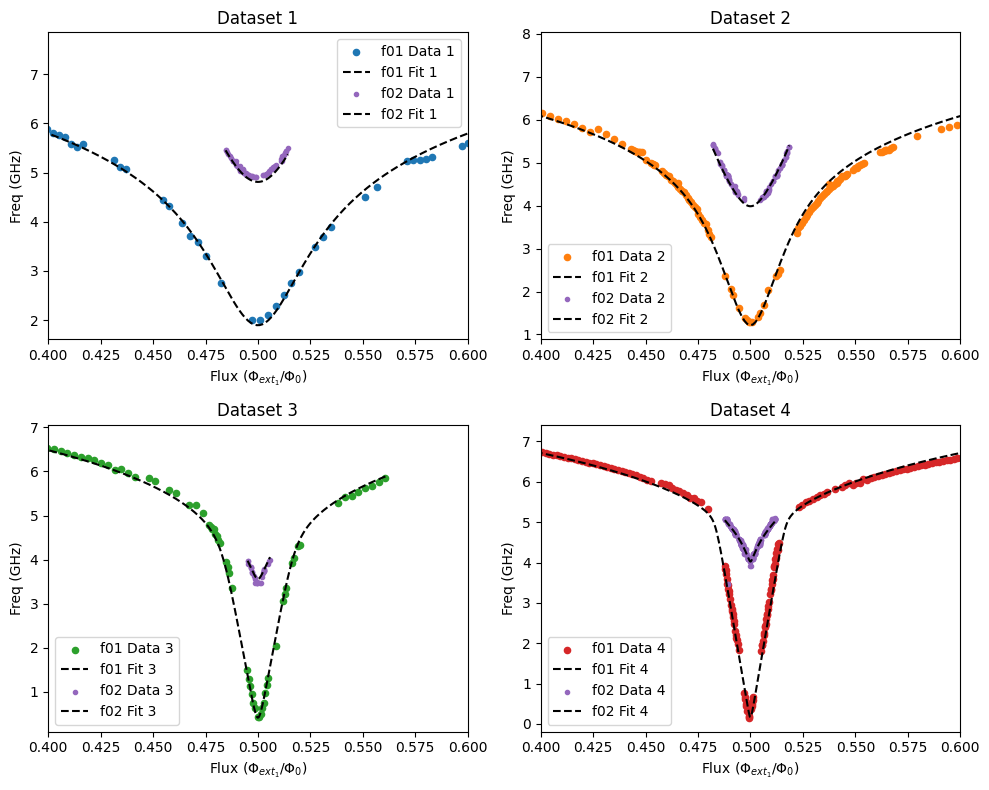

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
dataset_keys = ["1", "2", "3", "4"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']  # example colors

# Global fitted parameters
EJ1, EJ2, EJ3, EJ4, EJ5 = result.x[:5]
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731

for i, key in enumerate(dataset_keys):
    # --- f01 data ---
    ds, flux_shift = load_dataset(key)
    flux_f01 = ds.bias.values * 1.0753 + flux_shift
    freq_f01 = ds.transition_frequency.values * 1e-9
    axes[i].scatter(flux_f01, freq_f01, color=colors[i], s=20, label=f"f01 Data {key}")

    # --- f01 fit ---
    flux2 = DATASETS02[key]["flux2"]  # use fixed flux2
    flux_f01_smooth = np.linspace(flux_f01.min(), flux_f01.max(), 500)
    fit_freq_f01 = sweep_phi_ext_f01_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux_f01_smooth, dataset_key=key)
    axes[i].plot(flux_f01_smooth, fit_freq_f01, color='black', linestyle='--', label=f"f01 Fit {key}")

    # --- f02 data ---
    f02_data, _, _ = load_and_convert_local(files[key], DATASETS02[key]["flux_shift"])
    flux_f02 = f02_data[:, 0]
    freq_f02 = f02_data[:, 1]
    axes[i].scatter(flux_f02, freq_f02, color='tab:purple', marker='.', label=f"f02 Data {key}")

    # --- f02 fit ---
    flux_f02_smooth = np.linspace(flux_f02.min(), flux_f02.max(), 500)
    fit_freq_f02 = sweep_phi_ext_f02_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux_f02_smooth, dataset_key=key)
    axes[i].plot(flux_f02_smooth, fit_freq_f02, color='black', linestyle='--', label=f"f02 Fit {key}")

    axes[i].set_xlabel("Flux ($\Phi_{ext_1}/\Phi_0$)")
    axes[i].set_ylabel("Freq (GHz)")
    axes[i].set_title(f"Dataset {key}")
    axes[i].legend()
    axes[i].set_xlim(0.4, 0.6)

plt.tight_layout()
plt.show()

## Considering narrow f01 data

In [15]:
files_f01 = {
    "1": "Data/Q2_DS_1/DS_1_Qubit_spec_f01_narrow_extracted.h5",
    "2": "Data/Q2_DS_2/DS_2_Qubit_spec_f01_narrow_extracted.h5",
    "3": "Data/Q2_DS_3/DS_3_Qubit_spec_f01_narrow_extracted.h5",
    "4": "Data/Q2_DS_4/DS_4_Qubit_spec_f01_narrow_extracted.h5",
}


In [16]:
DATASETS011 = {
    "1": {"flux_shift": 1.7745, "flux2": 0.406635},
    "2": {"flux_shift": 1.77631, "flux2": 0.3955},
    "3": {"flux_shift": 1.778, "flux2": 0.37882},
    "4": {"flux_shift": 1.778, "flux2": 0.3676}
}

# Function to load, shift x, scale y
def load_and_convert_local(filename, flux_shift):
    with h5py.File(filename, "r") as f:
        data = f["peaks"][:].copy()  # Copy to avoid read-only
        columns = list(f["peaks"].attrs["columns"])
        description = f["peaks"].attrs["description"]
    
    # Identify x and y columns
    x_index = columns.index("x") if "x" in columns else 0
    y_index = columns.index("y") if "y" in columns else 1
    
    # Apply shift and scaling
    data[:, x_index] *= 1.0753
    data[:, x_index] += flux_shift
    data[:, y_index] *= 1e-9
    
    return data, columns, description

# Store converted datasets in variables
f01_1, f01_cols_1, f01_desc_1 = load_and_convert_local(files_f01["1"], DATASETS011["1"]["flux_shift"])
f01_2, f01_cols_2, f01_desc_2 = load_and_convert_local(files_f01["2"], DATASETS011["2"]["flux_shift"])
f01_3, f01_cols_3, f01_desc_3 = load_and_convert_local(files_f01["3"], DATASETS011["3"]["flux_shift"])
f01_4, f01_cols_4, f01_desc_4 = load_and_convert_local(files_f01["4"], DATASETS011["4"]["flux_shift"])

In [17]:

def combined_residuals(params):
    EJ1, EJ2, EJ3, EJ4, EJ5 = params[:5]
    residuals = []

    dataset_keys = ["1", "2", "3", "4"]

    for key in dataset_keys:
        # ---- f01 ----         
        ds_f01, flux_shift_f01, _ = load_and_convert_local(files_f01[key], DATASETS011[key]["flux_shift"])
        fluxes_f01 = ds_f01[:, 0] 
        target_f01 = ds_f01[:, 1] 

        # Use 'key' here
        model_f01 = fitting_function_f01_phase(fluxes_f01, EJ1, EJ2, EJ3, EJ4, EJ5, key)
        residuals.append(model_f01 - target_f01)

        # ---- f02 ----
        f02_data, _, _ = load_and_convert_local(files[key], DATASETS02[key]["flux_shift"])
        fluxes_f02 = f02_data[:, 0]
        target_f02 = f02_data[:, 1]

        model_f02 = fitting_function_f02_phase(fluxes_f02, EJ1, EJ2, EJ3, EJ4, EJ5, key)
        residuals.append(model_f02 - target_f02)

    return np.concatenate(residuals)


### Fitting

In [18]:
initial_guess = [70, 70, 70, 40, 40]  # [EJ1, EJ2, t1, EJ3_1...EJ3_4]
lower_bounds = [ 40, 40, 40, 35, 34]
upper_bounds = [ 88, 88, 95, 48, 45 ]


dataset_keys = ["1", "2", "3", "4"]


result = least_squares(combined_residuals, initial_guess, bounds=(lower_bounds, upper_bounds), verbose=2)
print("Fitted parameters:", result.x)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3666e+03                                    2.26e+03    
       1              2         3.9768e+02      9.69e+02       1.87e+01       2.79e+02    
       2              3         9.1957e+01      3.06e+02       1.30e+01       1.03e+02    
       3              4         3.2033e+01      5.99e+01       6.10e+00       4.44e+01    
       4              5         2.1805e+01      1.02e+01       3.56e+00       1.97e+01    
       5              6         2.0618e+01      1.19e+00       6.80e+00       1.55e+02    
       6              7         1.9053e+01      1.57e+00       2.02e+00       2.87e+00    
       7              9         1.8993e+01      5.94e-02       8.63e-01       5.32e+00    
       8             10         1.8773e+01      2.21e-01       1.35e+00       4.58e+00    
       9             11         1.8660e+01      1.13e-01       7.87e-01       2.80e+00    

In [19]:
EJ1, EJ2, EJ3, EJ4, EJ5 = result.x[:5]
flux2_list = result.x[5:]

EJL = EJ1+ EJ2
t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2

# print("=== Fitted Parameters ===")
print(f"EJ1 = {EJ1:.3f}")
print(f"EJ2 = {EJ2:.3f}")
print(f"EJ3  = {EJ3:.3f}")
print(f"EJ4  = {EJ4:.3f}")
print(f"EJ5  = {EJ5:.3f}")

print(f"t1 = {t1:.5f}")
for i, flux2 in enumerate(flux2_list):
    print(f"flux2 (dataset {dataset_keys[i]}) = {flux2:.3f}")


EJ1 = 61.822
EJ2 = 40.000
EJ3  = 95.000
EJ4  = 36.546
EJ5  = 36.547
t1 = 0.95407


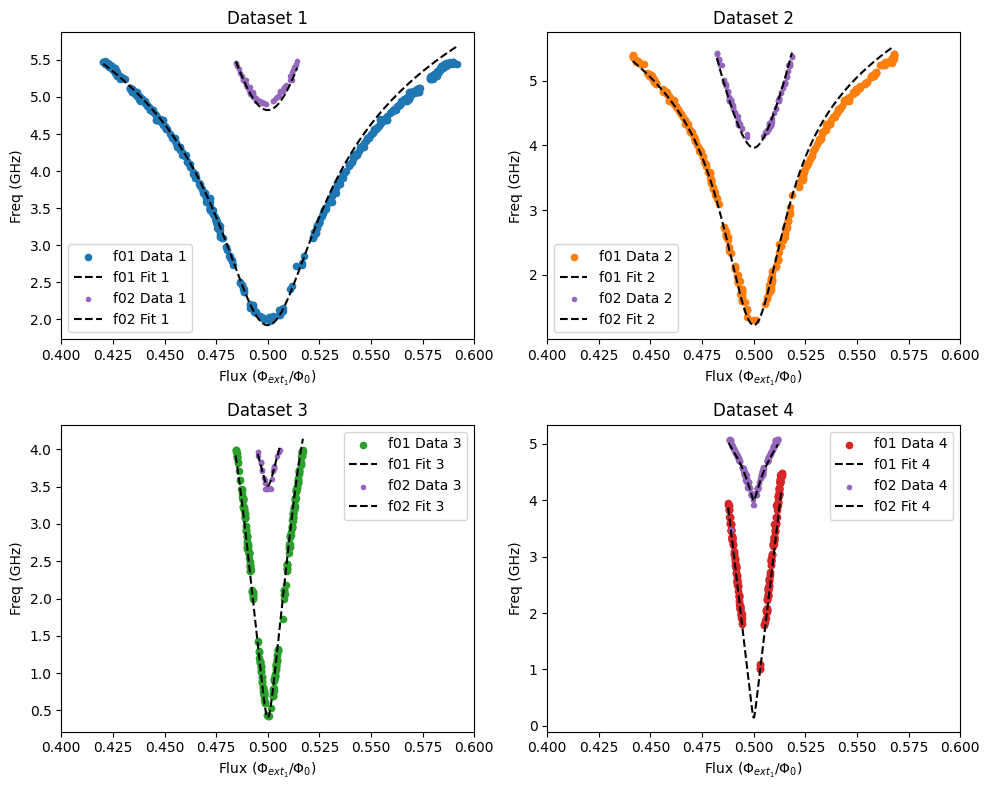

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
dataset_keys = ["1", "2", "3", "4"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']  # example colors

# Global fitted parameters
EJ1, EJ2, EJ3, EJ4, EJ5 = result.x[:5]

for i, key in enumerate(dataset_keys):
    # --- f01 data ---
    ds, flux_shift, _ = load_and_convert_local(files_f01[key], DATASETS011[key]["flux_shift"])
    flux_f01 = ds[:, 0] 
    freq_f01 = ds[:, 1]
    axes[i].scatter(flux_f01, freq_f01, color=colors[i], s=20, label=f"f01 Data {key}")

    # --- f01 fit ---
    flux2 = DATASETS011[key]["flux2"]  # use fixed flux2
    flux_f01_smooth = np.linspace(flux_f01.min(), flux_f01.max(), 500)
    fit_freq_f01 = sweep_phi_ext_f01_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5,flux_f01_smooth, dataset_key=key)
    axes[i].plot(flux_f01_smooth, fit_freq_f01, color='black', linestyle='--', label=f"f01 Fit {key}")

    # --- f02 data ---
    f02_data, _, _ = load_and_convert_local(files[key], DATASETS02[key]["flux_shift"])
    flux_f02 = f02_data[:, 0]
    freq_f02 = f02_data[:, 1]
    axes[i].scatter(flux_f02, freq_f02, color='tab:purple', marker='.', label=f"f02 Data {key}")

    # --- f02 fit ---
    flux_f02_smooth = np.linspace(flux_f02.min(), flux_f02.max(), 500)
    fit_freq_f02 = sweep_phi_ext_f02_phase_dataset(EJ1, EJ2, EJ3, EJ4, EJ5, flux_f02_smooth, dataset_key=key)
    axes[i].plot(flux_f02_smooth, fit_freq_f02, color='black', linestyle='--', label=f"f02 Fit {key}")

    axes[i].set_xlabel("Flux ($\Phi_{ext_1}/\Phi_0$)")
    axes[i].set_ylabel("Freq (GHz)")
    axes[i].set_title(f"Dataset {key}")
    axes[i].legend()
    axes[i].set_xlim(0.4, 0.6)

plt.tight_layout()
plt.show()